# 05 · Reusable containers

**Story so far:** features are cached and reproducible. Now Review Radar must score
every review in the corpus: a sentiment hint per review, at 100k-1M scale. By default
every task execution gets a fresh pod: schedule → pull image → start Python → import your
libraries → run → tear down. That overhead (10-60s, worse for ML images) is irrelevant
for one 2-hour training task and dominant for a million 2-second scorings.

**Reusable containers** keep a pool of warm pods that execute many tasks, concurrently,
while preserving Python process state between executions. They are the v2 successor to
v1 **Actors**, and for many workloads the Union-native alternative to reaching for a
separate distributed framework (that comparison is [06](./06-training-at-scale.ipynb)).

**Learning goals**

1. Configure `ReusePolicy` and reason about its capacity math
2. Load a model **once per pod** and serve many task executions from it
3. Build the production micro-batching pattern (reuse + traces + fan-out)
4. Recognize the high-parallelism failure modes reuse mitigates, and the new ones it
   introduces

> **Backend note:** reusable containers run on Union backends (any deployment model). The
> task image must include the `unionai-reuse` package, in the *image*, not on your laptop.

In [1]:
import asyncio
from datetime import timedelta
from typing import Dict, List

import flyte

flyte.init_from_config()

reuse_image = (
    flyte.Image.from_debian_base(name="workshop-reuse", python_version=(3, 12))
    .with_pip_packages("unionai-reuse>=0.1.15", "async-lru==2.3.0")
)

## 1. `ReusePolicy`

Four parameters, two axes:

| Parameter | Axis | Meaning |
|---|---|---|
| `replicas` | infrastructure | How many warm pods (int, or `(min, max)` for autoscaling) |
| `concurrency` | throughput | Task executions **per pod** at once (needs `async def` if > 1) |
| `scaledown_ttl` | lifecycle | Idle time before an *individual* pod is torn down |
| `idle_ttl` | lifecycle | Idle time before the *whole pool* shuts down |

**Total capacity = replicas × concurrency.** Resources are *per replica*, and concurrent
executions share them, so size memory for `concurrency` simultaneous reviews.

In [2]:
scoring_env = flyte.TaskEnvironment(
    name="score_pool",
    image=reuse_image,
    resources=flyte.Resources(cpu="1", memory="2Gi"),
    reusable=flyte.ReusePolicy(
        replicas=(2, 8),                       # autoscale 2..8 warm pods
        concurrency=8,                         # 8 async executions per pod
        scaledown_ttl=timedelta(minutes=5),    # per-pod idle teardown
        idle_ttl=timedelta(minutes=15),        # whole-pool idle shutdown
    ),
)
# Capacity: 2×8=16 concurrent scorings warm, bursting to 8×8=64.

# The driver coordinates thousands of children; give it memory, not reuse.
driver_env = flyte.TaskEnvironment(
    name="score_driver",
    image=reuse_image,
    resources=flyte.Resources(cpu="1", memory="4Gi"),
    depends_on=[scoring_env],
)

## 2. Warm state: load the scoring model once per pod

Because the Python process survives across executions, module-level state persists. A
disciplined way to exploit that is a cached async initializer: `@alru_cache` guarantees
one load even when concurrent executions race at pod startup. Review Radar's
scorer loads a (stand-in) sentiment lexicon once and scores thousands of reviews from it:

In [3]:
from async_lru import alru_cache


@alru_cache(maxsize=1)
async def get_sentiment_lexicon(version: str) -> Dict[str, float]:
    # In real life: torch.load / from_pretrained / open a DB pool; the expensive part.
    print(f"loading lexicon {version} (happens once per pod)")
    await asyncio.sleep(2)
    return {"love": 2.0, "solid": 1.0, "okay": 0.0, "disappointed": -1.5, "terrible": -2.5}


@scoring_env.task
async def score_review(text: str, lexicon_version: str = "v1") -> float:
    lexicon = await get_sentiment_lexicon(lexicon_version)  # instant after first call
    words = text.lower().split()
    return sum(lexicon.get(w, 0.0) for w in words) / max(len(words), 1)

In [4]:
@driver_env.task
async def score_corpus(texts: List[str]) -> List[float]:
    results: List[float] = []
    async for r in flyte.map.aio(score_review, texts, return_exceptions=True):
        if isinstance(r, Exception):
            raise r
        results.append(r)
    return results


sample = ["absolutely love this espresso machine"] * 25 + ["terrible trail shoes, arrived broken"] * 25
run = await flyte.run.aio(score_corpus, texts=sample)
print(run.url)
await run.wait.aio()
print(run.outputs()[:5])

> Building 2 images...

> Building image workshop-reuse for environment score_driver

> Building image workshop-reuse for environment score_pool

i Image workshop-reuse:2718ca80f157d702c09c5a9fce5466b3 was not found or has expired

> Image ghcr.io/flyteorg/workshop-reuse:2718ca80f157d702c09c5a9fce5466b3 not found, building...

...

✓ Built image for environment score_pool: 
356633062068.dkr.ecr.us-east-2.amazonaws.com/union/demo:workshop-reuse-2718ca80f157d702c09c5a9fce5466b3

Output()

https://demo.hosted.unionai.cloud/v2/domain/development/project/davide/runs/u9x4jdwqf4th9k67cv2m


Run 'u9x4jdwqf4th9k67cv2m' completed successfully.

([0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, -0.5, -0.5, -0.5, -0.5, -0.5, -0.5, -0.5, -0.5, -0.5, -0.5, -0.5, -0.5, -0.5, -0.5, -0.5, -0.5, -0.5, -0.5, -0.5, -0.5, -0.5, -0.5, -0.5, -0.5, -0.5],)


All 50 inputs processed using 7 Pods:

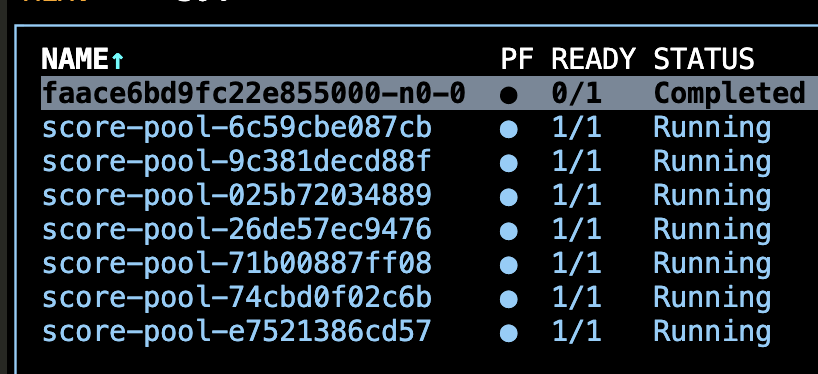

## 4. High-parallelism failure modes

The bottlenecks teams hit at this scale map directly onto this pattern:

| Failure mode | Without reuse | With reuse |
|---|---|---|
| **Image-pull throttling**: hundreds of pods pulling a multi-GB image stampede the registry / node disk | Frequent, at every scale-out | Pulls happen only when the pool grows |
| **Queueing delays**: 10k pods hit scheduler + autoscaler limits | Constant churn | Pool holds capacity; scheduler sees ~10 pods, not 10k |
| **Slow aborts**: cancelling a run must reap thousands of pods | Minutes of teardown | Abort marks in-flight executions; pods just go idle |
| **OOM patterns** | Per-pod, isolated | **Shared pod**: one hungry review can OOM-kill neighbors mid-flight; size memory for `concurrency` × worst item, or lower `concurrency` |
| **Cold-start cost** | Paid per task | Paid per pool scale-up |

CPU-bound or memory-spiky work wants `concurrency=1` (still keeps the warm-start win); I/O-bound work
can push concurrency much higher.

> 💬 **Discuss:** sort the customer's highest-volume workloads into I/O-bound vs
> memory-spiky. What `concurrency` and per-replica memory would you start each one at?

## 5. Coming from v1 Actors

| v1 (`union.actor`) | v2 |
|---|---|
| `ActorEnvironment(replica_count=2, ttl_seconds=300)` | `TaskEnvironment(reusable=ReusePolicy(replicas=(2,4), idle_ttl=timedelta(seconds=300)))` -> autoscaling|
| `@actor.task` | `@env.task` (same decorator as everything else) |
| `@actor_cache` for warm state | `@alru_cache` / `@lru_cache` on an initializer |
| Fixed `replica_count` | `replicas=(min, max)` autoscaling |
| TTL max 15 min | Configurable `scaledown_ttl` + `idle_ttl` |

**Story checkpoint:** the whole corpus can be scored on a warm pool at six-figure scale.
The scores and features are ready; time to train the real model.

## Further reading

- Union docs: [Reusable containers](https://www.union.ai/docs/v2/union/user-guide/task-configuration/reusable-containers/)
- Next: [06-training-at-scale](./06-training-at-scale.ipynb): training and
  hyperparameter search, including when a distributed framework (Ray) earns its place